# TensorFlow LSTM Many-to-One Daily Bitcoin Return Forecast

This notebook trains the standalone LSTM mean model. It uses the full EDA-selected daily feature set: stationary log-return dynamics, absolute/squared return dependence, rolling volatility, and persistent realized-volatility features. Raw price levels are excluded because the EDA stationarity tests reject them as suitable direct predictors.

The walk-forward design uses a fixed 180-day rolling training window and predicts the next daily log return from prior EDA-selected feature sequences.


In [1]:
from __future__ import annotations

import atexit
import hashlib
import importlib.util
import json
import random
import shutil
import socket
import subprocess
import sys
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

print('TensorFlow:', tf.__version__)


I0000 00:00:1780488526.165821 3544825 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780488526.621030 3544825 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780488539.811317 3544825 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


/mnt/c/Users/suchy/Studia/Masters/RR/LSTM_SGARCH_rr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths and core configuration
DATA_PATH = Path('data/BTC/BTC_USD_coinbase_spot_5min.csv')
ARTIFACTS_ROOT = Path('artifacts/lstm_walk_forward')
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

TIMESTAMP_COL = 'timestamp_utc'
TARGET_COL = 'target_daily_log_return'
FEATURE_COLS = [
    'log_return',
    'abs_log_return',
    'squared_log_return',
    'return_mean_7',
    'return_volatility_7',
    'abs_return_mean_7',
    'squared_return_mean_7',
    'return_mean_14',
    'return_volatility_14',
    'abs_return_mean_14',
    'squared_return_mean_14',
    'return_mean_30',
    'return_volatility_30',
    'abs_return_mean_30',
    'squared_return_mean_30',
    'log_return_lag_1',
    'abs_log_return_lag_1',
    'squared_log_return_lag_1',
    'log_return_lag_2',
    'abs_log_return_lag_2',
    'squared_log_return_lag_2',
    'log_return_lag_3',
    'abs_log_return_lag_3',
    'squared_log_return_lag_3',
    'log_return_lag_7',
    'abs_log_return_lag_7',
    'squared_log_return_lag_7',
    'realized_volatility',
    'log_realized_volatility',
    'realized_volatility_lag_1',
    'realized_volatility_30d_mean',
    'realized_volatility_90d_mean',
]

EDA_ROLLING_WINDOWS = [7, 14, 30]
EDA_LAGS = [1, 2, 3, 7]
EXPECTED_OBSERVATIONS_PER_DAY = 288
MIN_DAILY_COVERAGE = 0.95

TRAIN_WINDOW_MODE = 'rolling'
TRAIN_WINDOW_DAYS = 180
VALIDATION_PERIOD_DAYS = 90
TEST_PERIOD_DAYS = 30
VALIDATION_FOLD_STEP_DAYS = 7
VALIDATION_FOLD_HORIZON_DAYS = 3
TEST_FOLD_STEP_DAYS = 3
TEST_FOLD_HORIZON_DAYS = 3
GRID_VALIDATION_FOLD_LIMIT = 5

MAX_EPOCHS = 30
PATIENCE = 5
GRID_LIMIT = 36
SEED = 42

EPS = 1e-12
TRADING_DAYS = 365
TRANSACTION_COST_BPS = 5.0
GRID_SELECTION_WEIGHTS = {
    'rmse': 0.20,
    'mae': 0.10,
    'mape_pct': 0.05,
    'smape_pct': 0.05,
    'r2': 0.05,
    'correlation': 0.10,
    'direction_accuracy': 0.10,
    'strategy_total_return': 0.08,
    'strategy_annualized_return': 0.05,
    'strategy_annualized_volatility': 0.04,
    'strategy_sharpe': 0.12,
    'strategy_sortino': 0.08,
    'strategy_max_drawdown': 0.05,
    'strategy_hit_rate': 0.04,
    'strategy_turnover': 0.03,
}
GRID_SELECTION_DIRECTIONS = {
    'rmse': 'min',
    'mae': 'min',
    'mape_pct': 'min',
    'smape_pct': 'min',
    'r2': 'max',
    'correlation': 'max',
    'direction_accuracy': 'max',
    'strategy_total_return': 'max',
    'strategy_annualized_return': 'max',
    'strategy_annualized_volatility': 'min',
    'strategy_sharpe': 'max',
    'strategy_sortino': 'max',
    'strategy_max_drawdown': 'max',
    'strategy_hit_rate': 'max',
    'strategy_turnover': 'min',
}

HYPERPARAMETER_GRID = {
    'seq_len': [3, 5, 7, 10, 14, 21],
    'lstm_units': [16, 32],
    'dropout': [0.2],
    'learning_rate': [1e-3, 5e-4, 2e-4],
    'batch_size': [64],
}

LSTM_RUN_CONFIG = {
    'target_col': TARGET_COL,
    'feature_cols': FEATURE_COLS,
    'feature_selection_basis': 'EDA stationary return series and significant Ljung-Box tests for abs/squared returns and realized volatility',
    'eda_rolling_windows': EDA_ROLLING_WINDOWS,
    'eda_lags': EDA_LAGS,
    'expected_observations_per_day': EXPECTED_OBSERVATIONS_PER_DAY,
    'min_daily_coverage': MIN_DAILY_COVERAGE,
    'train_window_mode': TRAIN_WINDOW_MODE,
    'train_window_days': TRAIN_WINDOW_DAYS,
    'validation_period_days': VALIDATION_PERIOD_DAYS,
    'test_period_days': TEST_PERIOD_DAYS,
    'validation_fold_step_days': VALIDATION_FOLD_STEP_DAYS,
    'validation_fold_horizon_days': VALIDATION_FOLD_HORIZON_DAYS,
    'test_fold_step_days': TEST_FOLD_STEP_DAYS,
    'test_fold_horizon_days': TEST_FOLD_HORIZON_DAYS,
    'grid_validation_fold_limit': GRID_VALIDATION_FOLD_LIMIT,
    'hyperparameter_grid': HYPERPARAMETER_GRID,
    'grid_limit': GRID_LIMIT,
    'max_epochs': MAX_EPOCHS,
    'patience': PATIENCE,
    'trading_days': TRADING_DAYS,
    'transaction_cost_bps': TRANSACTION_COST_BPS,
    'grid_selection_method': 'weighted_rank_composite_validation_score',
    'grid_selection_weights': GRID_SELECTION_WEIGHTS,
    'grid_selection_directions': GRID_SELECTION_DIRECTIONS,
}
LSTM_RUN_CONFIG_SIGNATURE = hashlib.sha1(
    json.dumps(LSTM_RUN_CONFIG, sort_keys=True).encode('utf-8')
).hexdigest()[:12]
RUN_CONFIG_SIGNATURE = LSTM_RUN_CONFIG_SIGNATURE
RUN_DIR = ARTIFACTS_ROOT / 'runs' / RUN_CONFIG_SIGNATURE
ARTIFACTS_DIR = RUN_DIR
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
print('LSTM run signature:', RUN_CONFIG_SIGNATURE)
print('LSTM artifact dir:', ARTIFACTS_DIR)

USE_CUDA_IF_AVAILABLE = True
REQUIRE_CUDA = True
ENABLE_XLA = False
ENABLE_MIXED_PRECISION = True

AUTO_START_TENSORBOARD = True
TENSORBOARD_HOST = '127.0.0.1'
TENSORBOARD_PORT = 6006
TENSORBOARD_ROOT_LOGDIR = ARTIFACTS_ROOT / 'tensorboard' / RUN_CONFIG_SIGNATURE
TENSORBOARD_ROOT_LOGDIR.mkdir(parents=True, exist_ok=True)
TENSORBOARD_PROCESS: subprocess.Popen | None = None
HAS_TENSORBOARD = importlib.util.find_spec('tensorboard') is not None
TENSORBOARD_WARNING_EMITTED = False
TENSORBOARD_START_WARNING_EMITTED = False


LSTM run signature: 60536b3ea525
LSTM artifact dir: artifacts/lstm_walk_forward/runs/60536b3ea525


In [3]:
if not HAS_TENSORBOARD:
    AUTO_START_TENSORBOARD = False
    print('TensorBoard package is missing. Install with: uv pip install tensorboard')


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def configure_runtime_for_speed(
    use_cuda_if_available: bool = USE_CUDA_IF_AVAILABLE,
    require_cuda: bool = REQUIRE_CUDA,
    enable_xla: bool = ENABLE_XLA,
    enable_mixed_precision: bool = ENABLE_MIXED_PRECISION,
) -> list[tf.config.PhysicalDevice]:
    if enable_xla:
        tf.config.optimizer.set_jit(True)
    gpus = tf.config.list_physical_devices('GPU')
    if use_cuda_if_available and gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        if enable_mixed_precision:
            tf.keras.mixed_precision.set_global_policy('mixed_float16')
    else:
        tf.keras.mixed_precision.set_global_policy('float32')
    if require_cuda and not gpus:
        raise RuntimeError('CUDA GPU was required but not detected. Launch from WSL with: bash scripts/wsl_jupyter.sh and use kernel Python (LSTM WSL GPU)')
    print('Detected GPUs:', gpus)
    print('XLA enabled:', enable_xla)
    print('Mixed precision policy:', tf.keras.mixed_precision.global_policy())
    return gpus


set_seed(SEED)
GPUS = configure_runtime_for_speed()


Detected GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
XLA enabled: False
Mixed precision policy: <DTypePolicy "mixed_float16">


In [4]:
# Load 5-minute data and rebuild the EDA-selected daily modelling frame
raw = pd.read_csv(DATA_PATH)
raw[TIMESTAMP_COL] = pd.to_datetime(raw[TIMESTAMP_COL], utc=True)
raw = raw.sort_values(TIMESTAMP_COL).drop_duplicates(TIMESTAMP_COL, keep='last').reset_index(drop=True)
raw['log_close_5m'] = np.log(raw['close'])
raw['intraday_log_return'] = raw['log_close_5m'].diff()
raw['intraday_squared_return'] = raw['intraday_log_return'] ** 2
raw_idx = raw.set_index(TIMESTAMP_COL)

daily = raw_idx.resample('1D', closed='left', label='left').agg(
    open=('open', 'first'), high=('high', 'max'), low=('low', 'min'), close=('close', 'last'), volume=('volume', 'sum')
)
daily['observations'] = raw_idx['close'].resample('1D', closed='left', label='left').count().astype('int64')
daily['expected_observations'] = EXPECTED_OBSERVATIONS_PER_DAY
daily['coverage_ratio'] = daily['observations'] / daily['expected_observations']
daily = daily.dropna(subset=['open', 'high', 'low', 'close'])
daily = daily[daily['coverage_ratio'] >= MIN_DAILY_COVERAGE].copy()

realized_daily = pd.DataFrame({
    'realized_volatility': raw_idx['intraday_squared_return'].resample('1D', closed='left', label='left').sum().pow(0.5),
    'realized_observations': raw_idx['intraday_log_return'].resample('1D', closed='left', label='left').count(),
})
daily = daily.join(realized_daily)

daily['log_close'] = np.log(daily['close'])
daily['log_return'] = daily['log_close'].diff()
daily['abs_log_return'] = daily['log_return'].abs()
daily['squared_log_return'] = daily['log_return'] ** 2
daily['log_realized_volatility'] = np.log(daily['realized_volatility'].replace(0.0, np.nan))
daily['realized_volatility_lag_1'] = daily['realized_volatility'].shift(1)
daily['realized_volatility_30d_mean'] = daily['realized_volatility'].rolling(30).mean()
daily['realized_volatility_90d_mean'] = daily['realized_volatility'].rolling(90).mean()

for window in EDA_ROLLING_WINDOWS:
    daily[f'return_mean_{window}'] = daily['log_return'].rolling(window).mean()
    daily[f'return_volatility_{window}'] = daily['log_return'].rolling(window).std()
    daily[f'abs_return_mean_{window}'] = daily['abs_log_return'].rolling(window).mean()
    daily[f'squared_return_mean_{window}'] = daily['squared_log_return'].rolling(window).mean()

for lag in EDA_LAGS:
    daily[f'log_return_lag_{lag}'] = daily['log_return'].shift(lag)
    daily[f'abs_log_return_lag_{lag}'] = daily['abs_log_return'].shift(lag)
    daily[f'squared_log_return_lag_{lag}'] = daily['squared_log_return'].shift(lag)

daily[TARGET_COL] = daily['log_return']

df = daily.reset_index()[[TIMESTAMP_COL, *FEATURE_COLS, TARGET_COL]].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

dataset_start = df[TIMESTAMP_COL].min()
max_time = df[TIMESTAMP_COL].max()
test_start = max_time - pd.Timedelta(days=TEST_PERIOD_DAYS)
earliest_eval_start = dataset_start + pd.Timedelta(days=TRAIN_WINDOW_DAYS)
val_start = max(earliest_eval_start, test_start - pd.Timedelta(days=VALIDATION_PERIOD_DAYS))
if val_start >= test_start:
    raise RuntimeError('Validation period starts after test period. Check TRAIN_WINDOW_DAYS and VALIDATION_PERIOD_DAYS.')

split_masks = {
    'pre_validation_history': df[TIMESTAMP_COL] < val_start,
    'walk_forward_validation': (df[TIMESTAMP_COL] >= val_start) & (df[TIMESTAMP_COL] < test_start),
    'test': df[TIMESTAMP_COL] >= test_start,
}
split_summary = pd.DataFrame({name: {'rows': int(mask.sum()), 'start': df.loc[mask, TIMESTAMP_COL].min(), 'end': df.loc[mask, TIMESTAMP_COL].max()} for name, mask in split_masks.items()}).T

print('Prepared daily rows:', len(df))
print('Feature columns:', len(FEATURE_COLS))
print('Target:', 'r_t = log(P_t / P_{t-1}); each sequence predicts the next row return')
print('Training window days:', TRAIN_WINDOW_DAYS)
print('Validation starts:', val_start)
print('Test starts:', test_start)
display(split_summary)


Prepared daily rows: 3537
Feature columns: 32
Target: r_t = log(P_t / P_{t-1}); each sequence predicts the next row return
Training window days: 180
Validation starts: 2025-12-13 00:00:00+00:00
Test starts: 2026-03-13 00:00:00+00:00


,rows,start,end
pre_validation_history,3416,2016-07-13 00:00:00+00:00,2025-12-12 00:00:00+00:00
walk_forward_validation,90,2025-12-13 00:00:00+00:00,2026-03-12 00:00:00+00:00
test,31,2026-03-13 00:00:00+00:00,2026-04-12 00:00:00+00:00


In [5]:
def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int) -> tuple[np.ndarray, np.ndarray]:
    x_list: list[np.ndarray] = []
    y_list: list[float] = []
    for idx in range(seq_len, len(features)):
        x_list.append(features[idx - seq_len:idx])
        y_list.append(targets[idx])
    if not x_list:
        return (np.empty((0, seq_len, features.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.float32))
    return np.asarray(x_list, dtype=np.float32), np.asarray(y_list, dtype=np.float32)


def build_walk_forward_folds(data: pd.DataFrame, start_time: pd.Timestamp, end_time: pd.Timestamp, train_window_days: int, step_days: int, horizon_days: int, min_train_rows: int = 1) -> list[dict]:
    folds: list[dict] = []
    fold_id = 0
    cursor = pd.Timestamp(start_time)
    while cursor < end_time:
        eval_start = cursor
        eval_end = min(eval_start + pd.Timedelta(days=horizon_days), end_time)
        train_end = eval_start
        train_start = train_end - pd.Timedelta(days=train_window_days)
        train_rows = data[(data[TIMESTAMP_COL] >= train_start) & (data[TIMESTAMP_COL] < train_end)]
        eval_rows = data[(data[TIMESTAMP_COL] >= eval_start) & (data[TIMESTAMP_COL] < eval_end)]
        if len(train_rows) >= min_train_rows and len(eval_rows) > 0:
            if train_rows[TIMESTAMP_COL].max() >= eval_rows[TIMESTAMP_COL].min():
                raise RuntimeError('Walk-forward leakage detected: train labels overlap evaluation labels.')
            folds.append({'fold_id': fold_id, 'train_start': train_start, 'train_end': train_end, 'eval_start': eval_start, 'eval_end': eval_end, 'train_rows': int(len(train_rows)), 'eval_rows': int(len(eval_rows))})
            fold_id += 1
        cursor = cursor + pd.Timedelta(days=step_days)
    return folds


def select_evenly_spaced_folds(folds: list[dict], limit: int | None) -> list[dict]:
    if limit is None or limit <= 0 or len(folds) <= limit:
        return folds
    indices = np.linspace(0, len(folds) - 1, limit, dtype=int)
    selected: list[dict] = []
    seen: set[int] = set()
    for idx in indices:
        idx = int(idx)
        if idx not in seen:
            selected.append(folds[idx])
            seen.add(idx)
    return selected


def describe_folds(name: str, folds: list[dict]) -> None:
    fold_df = pd.DataFrame(folds)
    print(f'{name} folds: {len(folds)}')
    if not fold_df.empty:
        display(fold_df.head())
        display(fold_df.tail())


In [6]:
all_val_folds = build_walk_forward_folds(
    data=df,
    start_time=val_start,
    end_time=test_start,
    train_window_days=TRAIN_WINDOW_DAYS,
    step_days=VALIDATION_FOLD_STEP_DAYS,
    horizon_days=VALIDATION_FOLD_HORIZON_DAYS,
)
val_folds = select_evenly_spaced_folds(all_val_folds, GRID_VALIDATION_FOLD_LIMIT)

test_folds = build_walk_forward_folds(
    data=df,
    start_time=test_start,
    end_time=max_time,
    train_window_days=TRAIN_WINDOW_DAYS,
    step_days=TEST_FOLD_STEP_DAYS,
    horizon_days=TEST_FOLD_HORIZON_DAYS,
)

describe_folds('Validation candidates', all_val_folds)
describe_folds('Selected validation', val_folds)
describe_folds('Test', test_folds)


Validation candidates folds: 13


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
0,0,2025-06-16 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-16 00:00:00+00:00,179,3
1,1,2025-06-23 00:00:00+00:00,2025-12-20 00:00:00+00:00,2025-12-20 00:00:00+00:00,2025-12-23 00:00:00+00:00,179,3
2,2,2025-06-30 00:00:00+00:00,2025-12-27 00:00:00+00:00,2025-12-27 00:00:00+00:00,2025-12-30 00:00:00+00:00,179,3
3,3,2025-07-07 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-06 00:00:00+00:00,179,3
4,4,2025-07-14 00:00:00+00:00,2026-01-10 00:00:00+00:00,2026-01-10 00:00:00+00:00,2026-01-13 00:00:00+00:00,179,3


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
8,8,2025-08-11 00:00:00+00:00,2026-02-07 00:00:00+00:00,2026-02-07 00:00:00+00:00,2026-02-10 00:00:00+00:00,179,3
9,9,2025-08-18 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-17 00:00:00+00:00,179,3
10,10,2025-08-25 00:00:00+00:00,2026-02-21 00:00:00+00:00,2026-02-21 00:00:00+00:00,2026-02-24 00:00:00+00:00,179,3
11,11,2025-09-01 00:00:00+00:00,2026-02-28 00:00:00+00:00,2026-02-28 00:00:00+00:00,2026-03-03 00:00:00+00:00,179,3
12,12,2025-09-08 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-10 00:00:00+00:00,179,3


Selected validation folds: 5


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
0,0,2025-06-16 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-16 00:00:00+00:00,179,3
1,3,2025-07-07 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-06 00:00:00+00:00,179,3
2,6,2025-07-28 00:00:00+00:00,2026-01-24 00:00:00+00:00,2026-01-24 00:00:00+00:00,2026-01-27 00:00:00+00:00,179,3
3,9,2025-08-18 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-17 00:00:00+00:00,179,3
4,12,2025-09-08 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-10 00:00:00+00:00,179,3


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
0,0,2025-06-16 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-16 00:00:00+00:00,179,3
1,3,2025-07-07 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-06 00:00:00+00:00,179,3
2,6,2025-07-28 00:00:00+00:00,2026-01-24 00:00:00+00:00,2026-01-24 00:00:00+00:00,2026-01-27 00:00:00+00:00,179,3
3,9,2025-08-18 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-17 00:00:00+00:00,179,3
4,12,2025-09-08 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-10 00:00:00+00:00,179,3


Test folds: 10


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
0,0,2025-09-14 00:00:00+00:00,2026-03-13 00:00:00+00:00,2026-03-13 00:00:00+00:00,2026-03-16 00:00:00+00:00,179,3
1,1,2025-09-17 00:00:00+00:00,2026-03-16 00:00:00+00:00,2026-03-16 00:00:00+00:00,2026-03-19 00:00:00+00:00,179,3
2,2,2025-09-20 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-22 00:00:00+00:00,179,3
3,3,2025-09-23 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-03-25 00:00:00+00:00,179,3
4,4,2025-09-26 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-28 00:00:00+00:00,179,3


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
5,5,2025-09-29 00:00:00+00:00,2026-03-28 00:00:00+00:00,2026-03-28 00:00:00+00:00,2026-03-31 00:00:00+00:00,179,3
6,6,2025-10-02 00:00:00+00:00,2026-03-31 00:00:00+00:00,2026-03-31 00:00:00+00:00,2026-04-03 00:00:00+00:00,179,3
7,7,2025-10-05 00:00:00+00:00,2026-04-03 00:00:00+00:00,2026-04-03 00:00:00+00:00,2026-04-06 00:00:00+00:00,179,3
8,8,2025-10-08 00:00:00+00:00,2026-04-06 00:00:00+00:00,2026-04-06 00:00:00+00:00,2026-04-09 00:00:00+00:00,179,3
9,9,2025-10-11 00:00:00+00:00,2026-04-09 00:00:00+00:00,2026-04-09 00:00:00+00:00,2026-04-12 00:00:00+00:00,179,3


In [7]:
def build_model(seq_len: int, n_features: int, lstm_units: int, dropout: float, learning_rate: float) -> tf.keras.Model:
    layers: list[tf.keras.layers.Layer] = [
        tf.keras.layers.Input(shape=(seq_len, n_features)),
        tf.keras.layers.LSTM(lstm_units, recurrent_dropout=0.0),
    ]
    if dropout > 0.0:
        layers.append(tf.keras.layers.Dropout(dropout))
    layers.extend([tf.keras.layers.Dense(16, activation='relu'), tf.keras.layers.Dense(1, dtype='float32')])
    model = tf.keras.Sequential(layers)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse', metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])
    return model


def prepare_fold_data(data: pd.DataFrame, fold: dict, seq_len: int) -> dict | None:
    train_df = data[(data[TIMESTAMP_COL] >= fold['train_start']) & (data[TIMESTAMP_COL] < fold['train_end'])].copy()
    eval_df = data[(data[TIMESTAMP_COL] >= fold['eval_start']) & (data[TIMESTAMP_COL] < fold['eval_end'])].copy()
    if len(train_df) <= seq_len + 10 or len(eval_df) == 0:
        return None
    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_df[FEATURE_COLS])
    eval_features = scaler.transform(eval_df[FEATURE_COLS])
    train_targets = train_df[TARGET_COL].to_numpy(dtype=np.float32)
    eval_targets = eval_df[TARGET_COL].to_numpy(dtype=np.float32)
    x_all, y_all = make_sequences(train_features, train_targets, seq_len)
    if len(x_all) < 12:
        return None
    split_idx = int(len(x_all) * 0.8)
    if split_idx <= 0 or split_idx >= len(x_all):
        return None
    combined_features = np.vstack([train_features, eval_features])
    combined_targets = np.concatenate([train_targets, eval_targets])
    x_eval_list: list[np.ndarray] = []
    y_eval_list: list[float] = []
    eval_start_idx = len(train_df)
    for idx in range(eval_start_idx, len(combined_features)):
        start = idx - seq_len
        if start < 0:
            continue
        x_eval_list.append(combined_features[start:idx])
        y_eval_list.append(float(combined_targets[idx]))
    if not x_eval_list:
        return None
    return {
        'x_train': x_all[:split_idx], 'y_train': y_all[:split_idx],
        'x_val': x_all[split_idx:], 'y_val': y_all[split_idx:],
        'x_eval': np.asarray(x_eval_list, dtype=np.float32),
        'y_eval': np.asarray(y_eval_list, dtype=np.float32),
        'eval_timestamps': eval_df[TIMESTAMP_COL].to_numpy(),
    }


def is_port_open(host: str, port: int) -> bool:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.settimeout(0.2)
        return sock.connect_ex((host, port)) == 0


def ensure_tensorboard_running(log_dir: Path) -> str | None:
    global TENSORBOARD_PROCESS, TENSORBOARD_START_WARNING_EMITTED
    if not HAS_TENSORBOARD or not AUTO_START_TENSORBOARD:
        return None
    log_dir.mkdir(parents=True, exist_ok=True)
    url = f'http://{TENSORBOARD_HOST}:{TENSORBOARD_PORT}'
    if is_port_open(TENSORBOARD_HOST, TENSORBOARD_PORT):
        return url
    if TENSORBOARD_PROCESS is not None and TENSORBOARD_PROCESS.poll() is not None:
        TENSORBOARD_PROCESS = None
    if TENSORBOARD_PROCESS is None:
        cmd = [sys.executable, '-m', 'tensorboard.main', '--logdir', str(log_dir), '--host', TENSORBOARD_HOST, '--port', str(TENSORBOARD_PORT), '--reload_interval', '5']
        TENSORBOARD_PROCESS = subprocess.Popen(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for _ in range(20):
        if is_port_open(TENSORBOARD_HOST, TENSORBOARD_PORT):
            print(f'TensorBoard started: {url} (logdir={log_dir})')
            return url
        time.sleep(0.25)
    if not TENSORBOARD_START_WARNING_EMITTED:
        print(f'TensorBoard process launched but port {TENSORBOARD_PORT} is not ready yet.')
        TENSORBOARD_START_WARNING_EMITTED = True
    return url


def stop_tensorboard() -> None:
    global TENSORBOARD_PROCESS
    if TENSORBOARD_PROCESS is not None and TENSORBOARD_PROCESS.poll() is None:
        TENSORBOARD_PROCESS.terminate()
    TENSORBOARD_PROCESS = None


atexit.register(stop_tensorboard)


def forecast_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    denom = np.abs(y_true) + np.abs(y_pred) + EPS
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(err) / (np.abs(y_true) + EPS)) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / denom) * 100.0)
    sst = float(np.sum((y_true - y_true.mean()) ** 2))
    sse = float(np.sum(err ** 2))
    r2 = float(1.0 - sse / sst) if sst > EPS else float('nan')
    correlation = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > EPS and np.std(y_pred) > EPS) else float('nan')
    direction_accuracy = float(np.mean(np.sign(y_true) == np.sign(y_pred)))
    return {
        'rmse': rmse,
        'mae': mae,
        'mape_pct': mape,
        'smape_pct': smape,
        'r2': r2,
        'correlation': correlation,
        'direction_accuracy': direction_accuracy,
    }


def strategy_metrics_from_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    positions = np.sign(y_pred)
    positions = np.where(np.isfinite(positions), positions, 0.0)
    turnover = np.abs(np.diff(positions, prepend=0.0))
    transaction_cost = TRANSACTION_COST_BPS / 10_000.0
    returns = positions * y_true - transaction_cost * turnover
    if len(returns) == 0:
        return {
            'strategy_total_return': float('nan'),
            'strategy_annualized_return': float('nan'),
            'strategy_annualized_volatility': float('nan'),
            'strategy_sharpe': float('nan'),
            'strategy_sortino': float('nan'),
            'strategy_max_drawdown': float('nan'),
            'strategy_hit_rate': float('nan'),
            'strategy_turnover': float('nan'),
        }
    equity = np.exp(np.cumsum(returns))
    drawdown = equity / np.maximum.accumulate(equity) - 1.0
    volatility = float(np.std(returns, ddof=1) * np.sqrt(TRADING_DAYS)) if len(returns) > 1 else float('nan')
    annualized_return = float(np.exp(np.mean(returns) * TRADING_DAYS) - 1.0)
    sharpe = float((np.mean(returns) / (np.std(returns, ddof=1) + EPS)) * np.sqrt(TRADING_DAYS)) if len(returns) > 1 else float('nan')
    downside = returns[returns < 0]
    sortino = float((np.mean(returns) / (np.std(downside, ddof=1) + EPS)) * np.sqrt(TRADING_DAYS)) if len(downside) > 1 else float('nan')
    return {
        'strategy_total_return': float(equity[-1] - 1.0),
        'strategy_annualized_return': annualized_return,
        'strategy_annualized_volatility': volatility,
        'strategy_sharpe': sharpe,
        'strategy_sortino': sortino,
        'strategy_max_drawdown': float(np.min(drawdown)),
        'strategy_hit_rate': float(np.mean(returns > 0)),
        'strategy_turnover': float(np.mean(turnover)),
    }


def add_composite_scores(df: pd.DataFrame, score_col: str, prefix: str = '', suffix: str = '') -> pd.DataFrame:
    scored = df.copy()
    if scored.empty:
        scored[score_col] = []
        return scored
    weighted_score = pd.Series(0.0, index=scored.index, dtype=float)
    total_weight = 0.0
    for metric, weight in GRID_SELECTION_WEIGHTS.items():
        col = f'{prefix}{metric}{suffix}'
        if col not in scored.columns:
            continue
        direction = GRID_SELECTION_DIRECTIONS.get(metric, 'min')
        values = pd.to_numeric(scored[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
        valid = values.notna()
        rank_col = f'{col}_rank'
        if valid.sum() == 0:
            scored[rank_col] = np.nan
            continue
        filled = values.copy()
        if direction == 'min':
            worst = values[valid].max()
            fill_value = worst + abs(worst) + 1.0 if np.isfinite(worst) else 1.0
            ranks = filled.fillna(fill_value).rank(method='average', ascending=True)
        else:
            worst = values[valid].min()
            fill_value = worst - abs(worst) - 1.0 if np.isfinite(worst) else -1.0
            ranks = filled.fillna(fill_value).rank(method='average', ascending=False)
        normalized_rank = (ranks - 1.0) / max(len(scored) - 1, 1)
        if len(scored) == 1:
            normalized_rank = pd.Series(0.0, index=scored.index, dtype=float)
        scored[rank_col] = normalized_rank
        weighted_score = weighted_score + weight * normalized_rank
        total_weight += weight
    scored[score_col] = weighted_score / total_weight if total_weight > 0 else np.nan
    return scored


def keras_infer(model: tf.keras.Model, x: np.ndarray) -> np.ndarray:
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    return model(x_tensor, training=False).numpy().reshape(-1)


def train_one_fold(data: pd.DataFrame, fold: dict, params: dict, combo_dir: Path, fold_set_name: str) -> dict | None:
    global TENSORBOARD_WARNING_EMITTED
    fold_data = prepare_fold_data(data, fold, seq_len=params['seq_len'])
    if fold_data is None:
        return None
    fold_dir = combo_dir / fold_set_name / f"fold_{fold['fold_id']:03d}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = fold_dir / 'best_model.keras'
    backup_dir = fold_dir / f'backup_{RUN_CONFIG_SIGNATURE}'
    tensorboard_log_dir = TENSORBOARD_ROOT_LOGDIR / fold_set_name / combo_dir.name / f"fold_{fold['fold_id']:03d}"
    model = build_model(params['seq_len'], len(FEATURE_COLS), params['lstm_units'], params['dropout'], params['learning_rate'])
    callbacks: list[tf.keras.callbacks.Callback] = [
        tf.keras.callbacks.ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True, mode='min'),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
        tf.keras.callbacks.BackupAndRestore(backup_dir=str(backup_dir), delete_checkpoint=False),
    ]
    tensorboard_url = ensure_tensorboard_running(TENSORBOARD_ROOT_LOGDIR)
    if HAS_TENSORBOARD:
        callbacks.append(tf.keras.callbacks.TensorBoard(log_dir=str(tensorboard_log_dir), histogram_freq=0, write_graph=False, update_freq='epoch'))
    elif not TENSORBOARD_WARNING_EMITTED:
        print('TensorBoard callback disabled because the tensorboard package is not installed.')
        TENSORBOARD_WARNING_EMITTED = True
    history = model.fit(fold_data['x_train'], fold_data['y_train'], validation_data=(fold_data['x_val'], fold_data['y_val']), epochs=MAX_EPOCHS, batch_size=params['batch_size'], verbose=0, callbacks=callbacks)
    best_model = tf.keras.models.load_model(checkpoint_path, compile=False) if checkpoint_path.exists() else model
    y_pred = keras_infer(best_model, fold_data['x_eval'])
    metrics = forecast_metrics(fold_data['y_eval'], y_pred)
    metrics.update(strategy_metrics_from_predictions(fold_data['y_eval'], y_pred))
    positions = np.sign(y_pred)
    turnover = np.abs(np.diff(positions, prepend=0.0))
    strategy_return = positions * fold_data['y_eval'] - (TRANSACTION_COST_BPS / 10_000.0) * turnover
    pred_df = pd.DataFrame({TIMESTAMP_COL: fold_data['eval_timestamps'], 'y_true': fold_data['y_eval'], 'y_pred': y_pred, 'position': positions, 'turnover': turnover, 'strategy_return': strategy_return})
    pred_path = fold_dir / 'predictions.csv'
    pred_df.to_csv(pred_path, index=False)
    result = {'fold_id': fold['fold_id'], **metrics, 'model_path': str(checkpoint_path), 'predictions_path': str(pred_path), 'epochs_ran': len(history.history.get('loss', [])), 'tensorboard_log_dir': str(tensorboard_log_dir), 'tensorboard_url': tensorboard_url}
    del best_model, model
    tf.keras.backend.clear_session()
    return result


def build_grid(limit: int = GRID_LIMIT, seed: int = SEED) -> list[dict]:
    all_combinations = [
        {'seq_len': seq_len, 'lstm_units': lstm_units, 'dropout': dropout, 'learning_rate': learning_rate, 'batch_size': batch_size}
        for seq_len, lstm_units, dropout, learning_rate, batch_size in product(HYPERPARAMETER_GRID['seq_len'], HYPERPARAMETER_GRID['lstm_units'], HYPERPARAMETER_GRID['dropout'], HYPERPARAMETER_GRID['learning_rate'], HYPERPARAMETER_GRID['batch_size'])
    ]
    rng = random.Random(seed)
    rng.shuffle(all_combinations)
    return all_combinations[:limit]


def summarize_fold_records(fold_records: list[dict]) -> tuple[dict, dict | None]:
    if not fold_records:
        empty = {f'val_{metric}_mean': float('nan') for metric in GRID_SELECTION_WEIGHTS}
        empty.update({'val_rmse_mean': float('inf'), 'val_mae_mean': float('inf')})
        return empty, None
    fold_df = pd.DataFrame(fold_records)
    fold_scored = add_composite_scores(fold_df, score_col='fold_composite_score')
    numeric_metrics = [metric for metric in GRID_SELECTION_WEIGHTS if metric in fold_df.columns]
    summary = {f'val_{metric}_mean': float(pd.to_numeric(fold_df[metric], errors='coerce').mean()) for metric in numeric_metrics}
    best_fold = fold_scored.sort_values('fold_composite_score').iloc[0].to_dict()
    summary['best_fold_composite_score'] = float(best_fold['fold_composite_score'])
    return summary, best_fold


def write_best_metadata(output_dir: Path, best_row: pd.Series, best_model_path: Path) -> dict:
    best_params = {key: best_row[key].item() if hasattr(best_row[key], 'item') else best_row[key] for key in ['seq_len', 'lstm_units', 'dropout', 'learning_rate', 'batch_size']}
    source_model = str(best_row['best_fold_model'])
    shutil.copy2(source_model, best_model_path)
    metric_summary = {col: (float(best_row[col]) if pd.notna(best_row[col]) else None) for col in best_row.index if col.startswith('val_') and col.endswith('_mean')}
    metadata = {
        'best_combo': str(best_row['combo']),
        'best_selection_method': 'weighted_rank_composite_validation_score',
        'best_val_composite_score': float(best_row['composite_score']),
        'best_val_rmse_mean': float(best_row['val_rmse_mean']),
        'best_val_mae_mean': float(best_row['val_mae_mean']),
        'best_params': best_params,
        'source_model': source_model,
        'best_metric_summary': metric_summary,
        'run_config_signature': RUN_CONFIG_SIGNATURE,
        'run_dir': str(ARTIFACTS_DIR),
        **LSTM_RUN_CONFIG,
        'validation_candidate_folds': len(all_val_folds),
        'selected_validation_folds': len(val_folds),
        'test_folds': len(test_folds),
    }
    with (output_dir / 'best_model_metadata.json').open('w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2)
    return metadata


def run_grid_search(data: pd.DataFrame, folds: list[dict], grid: list[dict], output_dir: Path) -> tuple[pd.DataFrame, dict, Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    best_params: dict | None = None
    best_score = np.inf
    best_model_path = output_dir / 'best_model_overall.keras'
    results: list[dict] = []
    combo_iter = tqdm(enumerate(grid, start=1), total=len(grid), desc='LSTM grid search', unit='combo')
    for idx, params in combo_iter:
        combo_name = f'combo_{idx:03d}'
        combo_dir = output_dir / combo_name
        combo_dir.mkdir(parents=True, exist_ok=True)
        fold_records: list[dict] = []
        fold_iter = tqdm(folds, desc=f'{combo_name} validation folds', unit='fold', leave=False)
        for fold in fold_iter:
            fold_result = train_one_fold(data, fold, params, combo_dir, 'validation')
            if fold_result is not None:
                fold_records.append(fold_result)
                fold_iter.set_postfix(rmse=f"{fold_result['rmse']:.6f}", sharpe=f"{fold_result['strategy_sharpe']:.3f}", trained=len(fold_records))
        metric_summary, best_fold = summarize_fold_records(fold_records)
        row = {'combo': combo_name, 'n_folds_trained': len(fold_records), **params, **metric_summary, 'best_fold_model': best_fold['model_path'] if best_fold else None}
        results.append(row)
        scored_df = add_composite_scores(pd.DataFrame(results), score_col='composite_score', prefix='val_', suffix='_mean').sort_values('composite_score').reset_index(drop=True)
        scored_df.to_csv(output_dir / 'grid_search_results_live.csv', index=False)
        valid_best = scored_df[scored_df['best_fold_model'].notna() & scored_df['composite_score'].notna()]
        if not valid_best.empty:
            best_row = valid_best.iloc[0]
            metadata = write_best_metadata(output_dir, best_row, best_model_path)
            best_params = metadata['best_params']
            best_score = float(best_row['composite_score'])
        combo_score = scored_df.loc[scored_df['combo'] == combo_name, 'composite_score'].iloc[0]
        combo_rmse = row.get('val_rmse_mean', float('nan'))
        combo_iter.set_postfix(best=f'{best_score:.4f}' if np.isfinite(best_score) else 'inf', score=f'{combo_score:.4f}', rmse=f'{combo_rmse:.6f}', folds=len(fold_records))
        tqdm.write(f'[{idx:03d}/{len(grid):03d}] {combo_name} | composite={combo_score:.6f} | mean_val_rmse={combo_rmse:.8f} | folds={len(fold_records)}')
    results_df = add_composite_scores(pd.DataFrame(results), score_col='composite_score', prefix='val_', suffix='_mean').sort_values('composite_score').reset_index(drop=True)
    results_df.to_csv(output_dir / 'grid_search_results_final.csv', index=False)
    if results_df.empty or best_params is None:
        raise RuntimeError('No model could be trained. Try smaller seq_len or fewer folds.')
    final_best = results_df[results_df['best_fold_model'].notna() & results_df['composite_score'].notna()].iloc[0]
    metadata = write_best_metadata(output_dir, final_best, best_model_path)
    return results_df, metadata['best_params'], best_model_path


In [8]:
# Run grid search on selected validation folds
val_grid = build_grid(limit=GRID_LIMIT, seed=SEED)
print('Grid combinations:', len(val_grid))
print('Validation folds used for grid:', len(val_folds))

grid_dir = ARTIFACTS_DIR / 'grid_search'
results_df, best_params, best_model_path = run_grid_search(data=df, folds=val_folds, grid=val_grid, output_dir=grid_dir)

print('Best params:', best_params)
print('Best model saved at:', best_model_path)
display(results_df.head(10))


Grid combinations: 36
Validation folds used for grid: 5


combo_001 validation folds:   0%|                                                                                                                                                                                                                                    | 0/5 [00:00<?, ?fold/s]I0000 00:00:1780488547.859549 3544825 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21456 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


TensorBoard process launched but port 6006 is not ready yet.


E0000 00:00:1780488554.382592 3544825 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1780488554.423443 3545038 cuda_dnn.cc:461] Loaded cuDNN version 92300

combo_001 validation folds:  40%|███████████████████████████████████████████████████████████████████████▏                                                                                                          | 2/5 [00:27<00:41, 13.96s/fold, rmse=0.086564, sharpe=-27.888, trained=2]

TensorBoard started: http://127.0.0.1:6006 (logdir=artifacts/lstm_walk_forward/tensorboard/60536b3ea525)


...


LSTM grid search:  97%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████     | 35/36 [13:31<00:24, 24.62s/combo, best=0.0867, folds=5, rmse=0.087350, score=0.2283]

[035/036] combo_035 | composite=0.228328 | mean_val_rmse=0.08734979 | folds=5



LSTM grid search: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [13:50<00:00, 23.06s/combo, best=0.0905, folds=5, rmse=0.093728, score=0.5299]

[036/036] combo_036 | composite=0.529950 | mean_val_rmse=0.09372753 | folds=5
Best params: {'seq_len': 10, 'lstm_units': 32, 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 64}
Best model saved at: artifacts/lstm_walk_forward/runs/60536b3ea525/grid_search/best_model_overall.keras


,combo,n_folds_trained,seq_len,lstm_units,dropout,learning_rate,batch_size,val_rmse_mean,val_mae_mean,val_mape_pct_mean,...,val_direction_accuracy_mean_rank,val_strategy_total_return_mean_rank,val_strategy_annualized_return_mean_rank,val_strategy_annualized_volatility_mean_rank,val_strategy_sharpe_mean_rank,val_strategy_sortino_mean_rank,val_strategy_max_drawdown_mean_rank,val_strategy_hit_rate_mean_rank,val_strategy_turnover_mean_rank,composite_score
0,combo_030,5,10,32,0.2,0.0002,64,0.094115,0.079819,2117.481574,...,0.057143,0.028571,0.028571,0.171429,0.028571,0.014286,0.028571,0.057143,0.428571,0.090476
1,combo_011,5,21,16,0.2,0.0005,64,0.096315,0.088543,3112.901916,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.971429,0.000000,0.000000,0.657143,0.148120
2,combo_020,5,14,16,0.2,0.0010,64,0.134553,0.124114,2997.712658,...,0.185714,0.200000,0.200000,0.600000,0.142857,0.114286,0.200000,0.242857,0.128571,0.210401
3,combo_035,5,3,16,0.2,0.0005,64,0.087350,0.077100,2473.573880,...,0.271429,0.114286,0.314286,0.742857,0.200000,0.085714,0.142857,0.242857,1.000000,0.226316
4,combo_034,5,7,32,0.2,0.0002,64,0.084182,0.071745,1981.889117,...,0.600000,0.457143,0.342857,0.257143,0.485714,0.514286,0.371429,0.457143,0.785714,0.297870
5,combo_001,5,5,32,0.2,0.0010,64,0.108500,0.097871,5537.626090,...,0.457143,0.285714,0.057143,0.085714,0.428571,0.342857,0.314286,0.657143,0.657143,0.318045
6,combo_029,5,3,32,0.2,0.0010,64,0.146534,0.140584,10896.207566,...,0.185714,0.142857,0.171429,0.714286,0.114286,0.014286,0.085714,0.242857,0.428571,0.361153
7,combo_033,5,7,32,0.2,0.0010,64,0.153742,0.143731,4224.309013,...,0.128571,0.171429,0.371429,0.800000,0.257143,0.971429,0.271429,0.128571,0.428571,0.377318
8,combo_006,5,10,16,0.2,0.0005,64,0.157209,0.149118,11464.528665,...,0.028571,0.057143,0.114286,0.514286,0.057143,0.971429,0.271429,0.028571,0.128571,0.380702
9,combo_032,5,7,16,0.2,0.0002,64,0.091490,0.080439,6243.867833,...,0.600000,0.571429,0.400000,0.342857,0.657143,0.714286,0.600000,0.657143,0.428571,0.384962


In [9]:
def evaluate_on_folds(data: pd.DataFrame, folds: list[dict], params: dict, output_dir: Path, fold_set_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_dir.mkdir(parents=True, exist_ok=True)
    all_fold_metrics: list[dict] = []
    all_preds: list[pd.DataFrame] = []
    fold_iter = tqdm(folds, desc=f'LSTM {fold_set_name} folds', unit='fold')
    for fold in fold_iter:
        fold_result = train_one_fold(data=data, fold=fold, params=params, combo_dir=output_dir, fold_set_name=fold_set_name)
        if fold_result is None:
            continue
        all_fold_metrics.append(fold_result)
        fold_iter.set_postfix(rmse=f"{fold_result['rmse']:.6f}", trained=len(all_fold_metrics))
        pred_df = pd.read_csv(fold_result['predictions_path'])
        pred_df['fold_id'] = fold_result['fold_id']
        all_preds.append(pred_df)
    if not all_fold_metrics:
        raise RuntimeError(f'No folds trained for {fold_set_name}')
    metrics_df = pd.DataFrame(all_fold_metrics).sort_values('fold_id').reset_index(drop=True)
    preds_df = pd.concat(all_preds, ignore_index=True)
    metrics_df.to_csv(output_dir / f'{fold_set_name}_fold_metrics.csv', index=False)
    preds_df.to_csv(output_dir / f'{fold_set_name}_predictions.csv', index=False)
    return metrics_df, preds_df


In [10]:
final_dir = ARTIFACTS_DIR / 'final_evaluation'
val_metrics_df, val_preds_df = evaluate_on_folds(df, val_folds, best_params, final_dir, 'validation')
test_metrics_df, test_preds_df = evaluate_on_folds(df, test_folds, best_params, final_dir, 'test')

final_eval_metadata = {'run_config_signature': RUN_CONFIG_SIGNATURE, 'run_dir': str(ARTIFACTS_DIR), 'best_params': best_params, **LSTM_RUN_CONFIG, 'validation_candidate_folds': len(all_val_folds), 'selected_validation_folds': len(val_folds), 'test_folds': len(test_folds), 'final_evaluation_dir': str(final_dir)}
with (final_dir / 'final_evaluation_metadata.json').open('w', encoding='utf-8') as f:
    json.dump(final_eval_metadata, f, indent=2)

latest_run = {'run_config_signature': RUN_CONFIG_SIGNATURE, 'run_dir': str(ARTIFACTS_DIR), 'grid_search_dir': str(grid_dir), 'best_model_path': str(best_model_path), 'best_model_metadata_path': str(grid_dir / 'best_model_metadata.json'), 'final_evaluation_dir': str(final_dir), 'test_predictions_path': str(final_dir / 'test_predictions.csv')}
with (ARTIFACTS_ROOT / 'latest_run.json').open('w', encoding='utf-8') as f:
    json.dump(latest_run, f, indent=2)

print('Final evaluation metadata:', final_dir / 'final_evaluation_metadata.json')
print('Latest run pointer:', ARTIFACTS_ROOT / 'latest_run.json')
print('Validation fold metrics (mean):')
display(val_metrics_df[['rmse', 'mae']].mean().to_frame('value'))
print('Test fold metrics (mean):')
display(test_metrics_df[['rmse', 'mae']].mean().to_frame('value'))


LSTM test folds: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:57<00:00,  5.75s/fold, rmse=0.082594, trained=10]

Final evaluation metadata: artifacts/lstm_walk_forward/runs/60536b3ea525/final_evaluation/final_evaluation_metadata.json
Latest run pointer: artifacts/lstm_walk_forward/latest_run.json
Validation fold metrics (mean):


,value
rmse,0.088134
mae,0.081764


Test fold metrics (mean):


,value
rmse,0.131068
mae,0.121692


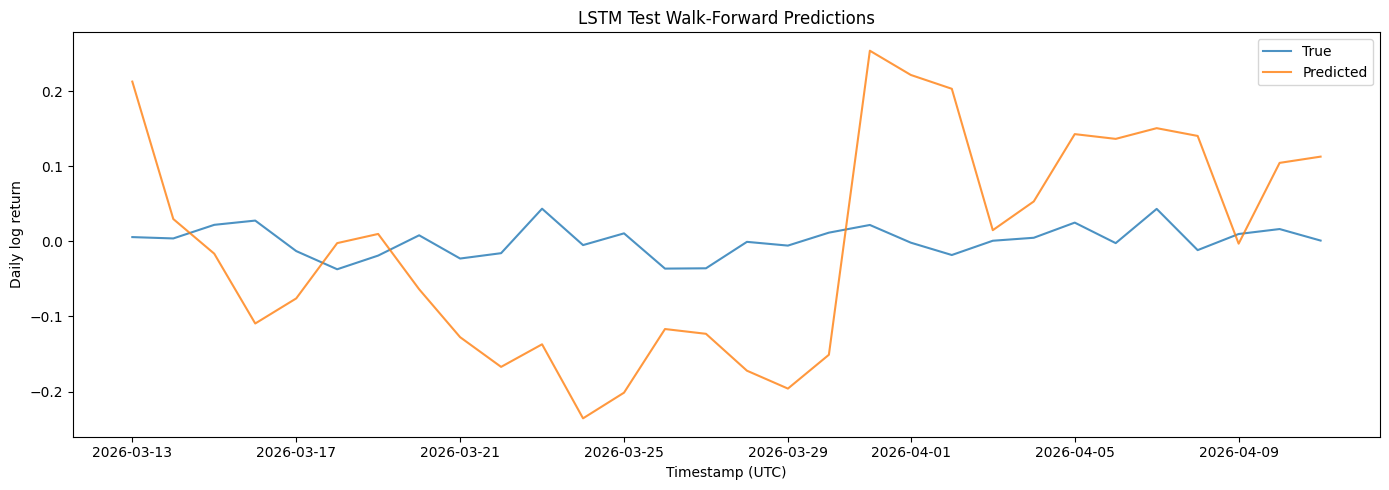

{'run_config_signature': '60536b3ea525',
 'run_dir': 'artifacts/lstm_walk_forward/runs/60536b3ea525',
 'val_rmse_mean': 0.08813388214857758,
 'val_mae_mean': 0.08176447691900345,
 'test_rmse_mean': 0.13106781419842833,
 'test_mae_mean': 0.12169228605537985,
 'best_params': {'seq_len': 10,
  'lstm_units': 32,
  'dropout': 0.2,
  'learning_rate': 0.0002,
  'batch_size': 64}}

In [11]:
# Quick diagnostics
plt.figure(figsize=(14, 5))
plot_df = test_preds_df.copy()
plot_df[TIMESTAMP_COL] = pd.to_datetime(plot_df[TIMESTAMP_COL], utc=True)
plot_df = plot_df.sort_values(TIMESTAMP_COL)
plt.plot(plot_df[TIMESTAMP_COL], plot_df['y_true'], label='True', alpha=0.8)
plt.plot(plot_df[TIMESTAMP_COL], plot_df['y_pred'], label='Predicted', alpha=0.8)
plt.title('LSTM Test Walk-Forward Predictions')
plt.xlabel('Timestamp (UTC)')
plt.ylabel('Daily log return')
plt.legend()
plt.tight_layout()
plt.show()

summary = {'run_config_signature': RUN_CONFIG_SIGNATURE, 'run_dir': str(ARTIFACTS_DIR), 'val_rmse_mean': float(val_metrics_df['rmse'].mean()), 'val_mae_mean': float(val_metrics_df['mae'].mean()), 'test_rmse_mean': float(test_metrics_df['rmse'].mean()), 'test_mae_mean': float(test_metrics_df['mae'].mean()), 'best_params': best_params}
with (ARTIFACTS_DIR / 'summary.json').open('w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
summary
